# **PART 1: Multimodal Sentiment & Outlier Analysis**

**Install Dependencies**

In [1]:

!pip install transformers sentence-transformers scikit-learn seaborn plotly pillow requests

**Data Preparation**

In [19]:
import pandas as pd
import numpy as np

df = pd.read_excel("Riize AllKpop Master.xlsx")

# Combine text fields
df["text_combined"] = df["Headline"].fillna('') + " " + df["Summary"].fillna('')

# Clean numeric column
df["Total Interactions"] = pd.to_numeric(df["Total Interactions"], errors="coerce")

df = df.dropna(subset=["text_combined", "Total Interactions"])
df.reset_index(drop=True, inplace=True)

df.head()

,Published,Headline,Headline Word Count,Summary,Link,Domain,Authors,Country,Image Link,Total Interactions,...,X Overperforming,Highest Velocity,Keywords,Facebook Interactions,Facebook Likes,Facebook Shares,Facebook Comments,X Influencer Shares,Pinterest,text_combined
0,2023-07-31 00:46:50,SM Entertainment to reportedly reveal all 7 me...,19.0,SM Entertainment to reportedly reveal all 7 me...,https://www.allkpop.com/article/2023/07/sm-ent...,allkpop.com,jieun-im,South Korea,https://img.newswhip.com/safeImage?url=https%3...,4342.0,...,0.81x,675.0,"allkpop,RIIZE",3764.0,0.0,0.0,0.0,578.0,0.0,SM Entertainment to reportedly reveal all 7 me...
1,2023-07-31 22:19:49,This member from SM's upcoming boy group RIIZE...,19.0,"In the ever-evolving world of K-pop, SM Entert...",https://www.allkpop.com/article/2023/07/this-m...,allkpop.com,Sophie-Ha,South Korea,https://img.newswhip.com/safeImage?url=https%3...,5050.0,...,-0.17x,317.0,"allkpop,RIIZE",4860.0,0.0,0.0,0.0,187.0,3.0,This member from SM's upcoming boy group RIIZE...
2,2023-08-01 06:56:23,K-netizens react to an alleged pre-debut photo...,14.0,Along with the official introduction of all th...,https://www.allkpop.com/article/2023/08/k-neti...,allkpop.com,Susan-Han,South Korea,https://img.newswhip.com/safeImage?url=https%3...,979.0,...,-0.56x,146.0,"allkpop,RIIZE",950.0,0.0,0.0,0.0,29.0,0.0,K-netizens react to an alleged pre-debut photo...
3,2023-08-02 05:43:44,SM Entertainment reveals sales and operating p...,19.0,"On August 2 KST, SM Entertainment published it...",https://www.allkpop.com/article/2023/08/sm-ent...,allkpop.com,Susan-Han,South Korea,https://img.newswhip.com/safeImage?url=https%3...,1930.0,...,-0.46x,365.0,"allkpop,aespa, D.O., Taeyeon, Hyoyeon, NCT, Wa...",1860.0,0.0,0.0,0.0,70.0,0.0,SM Entertainment reveals sales and operating p...
4,2023-08-02 18:50:44,K-netizens compare the graduation photos of NC...,14.0,"In a recent online community post, K-netizens ...",https://www.allkpop.com/article/2023/08/k-neti...,allkpop.com,Sophie-Ha,South Korea,https://img.newswhip.com/safeImage?url=https%3...,1544.0,...,-0.56x,105.0,"allkpop,NCT Dream, RIIZE",1506.0,0.0,0.0,0.0,30.0,8.0,K-netizens compare the graduation photos of NC...


**Text Sentiment Analysis (BERT - 3 Class)**

In [20]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

def get_text_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]['label']

        if result == "LABEL_2":
            return "Positive"
        elif result == "LABEL_0":
            return "Negative"
        else:
            return "Neutral"
    except:
        return "Neutral"

df["text_sentiment"] = df["text_combined"].apply(get_text_sentiment)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [21]:
df["text_sentiment"]

,text_sentiment
0,Neutral
1,Positive
2,Neutral
3,Neutral
4,Positive
...,...
452,Neutral
453,Neutral
454,Neutral
455,Neutral


**Image Sentiment Analysis (CLIP)**

In [5]:
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

labels = ["happy", "neutral", "sad", "offensive", "violent"]

def get_image_sentiment(url):
    try:
        image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

        inputs = clip_processor(text=labels, images=image, return_tensors="pt", padding=True)
        outputs = clip_model(**inputs)

        probs = outputs.logits_per_image.softmax(dim=1).detach().numpy()[0]
        return labels[probs.argmax()]

    except:
        return "unknown"

df["image_sentiment"] = df["Image Link"].apply(get_image_sentiment)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [6]:
df["image_sentiment"]

,image_sentiment
0,happy
1,offensive
2,offensive
3,violent
4,offensive
...,...
452,violent
453,happy
454,violent
455,unknown


**Multimodal Outlier Detection**

In [7]:
outliers = df[
    (df["text_sentiment"] == "Neutral") &
    (df["image_sentiment"].isin(["offensive", "violent"]))
]

print("Total Outliers Found:", len(outliers))
outliers[["Headline", "text_sentiment", "image_sentiment"]]

Total Outliers Found: 151


,Headline,text_sentiment,image_sentiment
2,K-netizens react to an alleged pre-debut photo...,Neutral,offensive
3,SM Entertainment reveals sales and operating p...,Neutral,violent
6,SM Entertainment's new boy group RIIZE unveils...,Neutral,violent
8,RIIZE continues to gear up for their debut wit...,Neutral,violent
9,RIIZE invites fans to their practice room in t...,Neutral,violent
...,...,...,...
441,"aespa, RIIZE, UNIS and more announced as winne...",Neutral,violent
443,Check out the winners of '2024 Korea Grand Mus...,Neutral,offensive
450,"Key, NCT 127, and more join ‘2024 SBS Gayo Dae...",Neutral,offensive
452,Yesung and Wonbin team up for an acoustic rend...,Neutral,violent


**Sentiment Distribution**

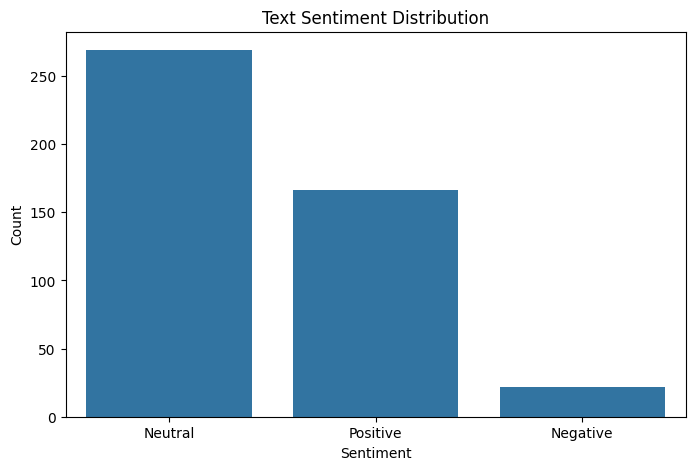

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="text_sentiment")
plt.title("Text Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

**Sentiment vs Engagement (Scatter + Regression)**

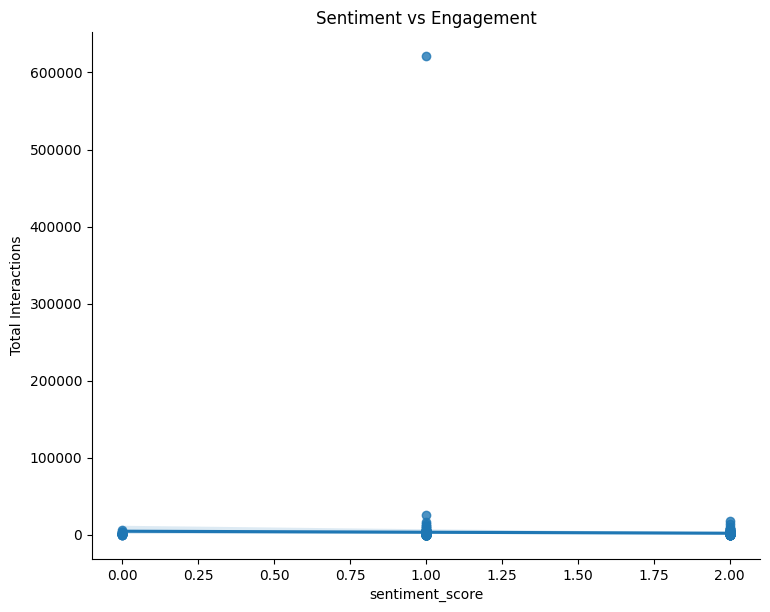

In [19]:
sentiment_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["sentiment_score"] = df["text_sentiment"].map(sentiment_map)

sns.lmplot(
    data=df,
    x="sentiment_score",
    y="Total Interactions",
    height=6,
    aspect=1.3
)

plt.title("Sentiment vs Engagement")
plt.show()



**Sentiment Density (Embedding-based)**

In [11]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

embedder = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = embedder.encode(df["text_combined"].tolist())

dist_matrix = cosine_distances(embeddings)

density_results = {}

for sentiment in ["Positive", "Neutral", "Negative"]:
    idx = df[df["text_sentiment"] == sentiment].index

    if len(idx) > 1:
        sub_dist = dist_matrix[np.ix_(idx, idx)]
        density_results[sentiment] = sub_dist.mean()

print("Sentiment Density:", density_results)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentiment Density: {'Positive': np.float32(0.64386725), 'Neutral': np.float32(0.6996239), 'Negative': np.float32(0.60050774)}


**Density Visualization (KDE Plot)**

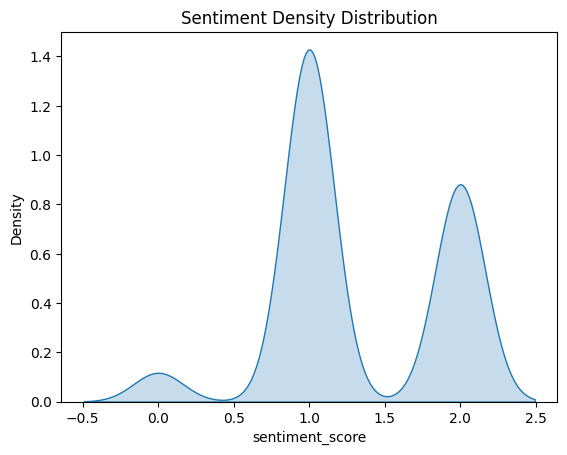

In [12]:
sns.kdeplot(data=df, x="sentiment_score", fill=True)
plt.title("Sentiment Density Distribution")
plt.show()

**Correlation & Regression Analysis**

In [13]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# Correlation
r, p = pearsonr(df["sentiment_score"], df["Total Interactions"])

print("Correlation (r):", r)
print("p-value:", p)

# Regression
X = df[["sentiment_score"]]
y = df["Total Interactions"]

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Correlation (r): -0.02508721467120175
p-value: 0.5927059881797507
Coefficient: -1305.6164065360845
Intercept: 4439.775326180416


# **PART 2: Contrast Analysis**

**Dataset Splitting**

In [20]:
import pandas as pd

# Ensure datetime format
df["Published"] = pd.to_datetime(df["Published"], errors="coerce")

# Define date range
start_date = "2023-07-31"
end_date = "2023-09-03"

# Subsets
df_period1 = df[(df["Published"] >= start_date) & (df["Published"] <= end_date)]
df_period2 = df[~((df["Published"] >= start_date) & (df["Published"] <= end_date))]

print("Period 1 size:", len(df_period1))
print("Period 2 size:", len(df_period2))

Period 1 size: 45
Period 2 size: 412


**Sentiment Distribution Comparison**

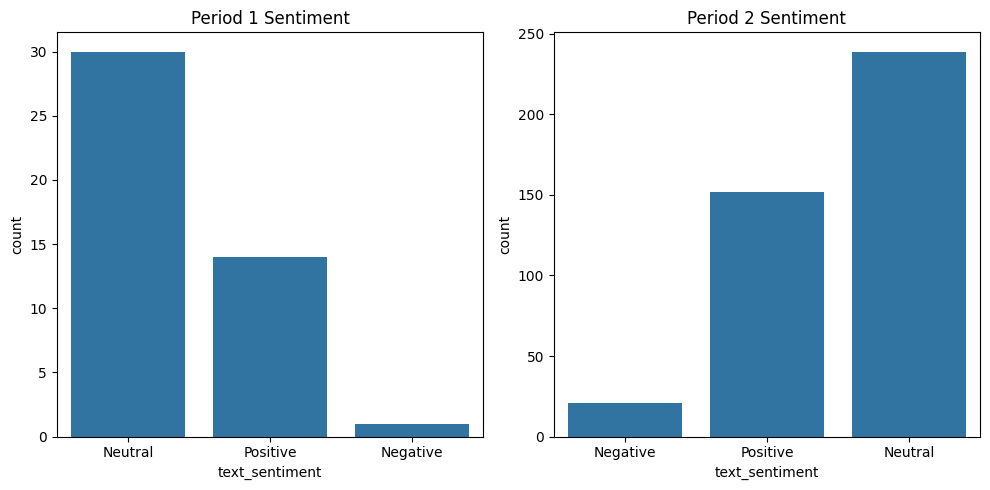

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(data=df_period1, x="text_sentiment")
plt.title("Period 1 Sentiment")

plt.subplot(1,2,2)
sns.countplot(data=df_period2, x="text_sentiment")
plt.title("Period 2 Sentiment")

plt.tight_layout()
plt.show()

**Correlation Comparison Analysis**

In [22]:
from scipy.stats import pearsonr

def compute_corr(data):
    data = data.dropna(subset=["sentiment_score", "Total Interactions"])
    if len(data) > 2:
        r, p = pearsonr(data["sentiment_score"], data["Total Interactions"])
        return r, p
    return None, None

r1, p1 = compute_corr(df_period1)
r2, p2 = compute_corr(df_period2)

print("Period 1 -> r:", r1, "p:", p1)
print("Period 2 -> r:", r2, "p:", p2)

Period 1 -> r: -0.1757437689020915 p: 0.24818683594751398
Period 2 -> r: -0.025394911747173708 p: 0.6072679139798223


**Regression Analysis**

In [23]:
from sklearn.linear_model import LinearRegression

def run_regression(data):
    data = data.dropna(subset=["sentiment_score", "Total Interactions"])

    if len(data) > 2:
        X = data[["sentiment_score"]]
        y = data["Total Interactions"]

        model = LinearRegression()
        model.fit(X, y)

        return model.coef_[0], model.intercept_

    return None, None

coef1, intercept1 = run_regression(df_period1)
coef2, intercept2 = run_regression(df_period2)

print("Period 1 Coef:", coef1)
print("Period 2 Coef:", coef2)

Period 1 Coef: -600.7470355731225
Period 2 Coef: -1376.8709257959995


**Scatter Plot with Regression**

Text(0.5, 1.0, 'Period 2: Sentiment vs Engagement')

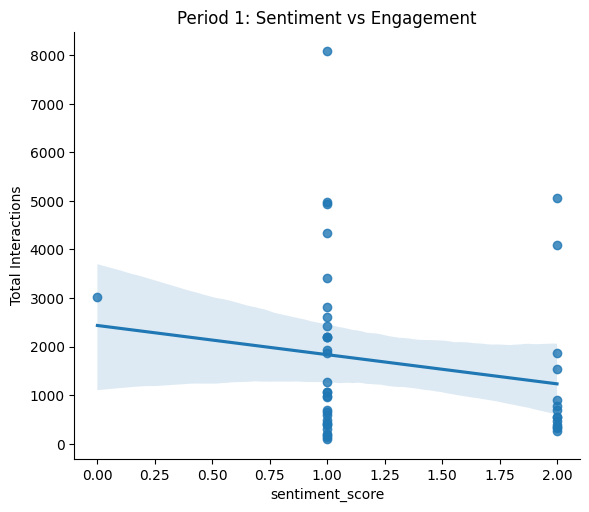

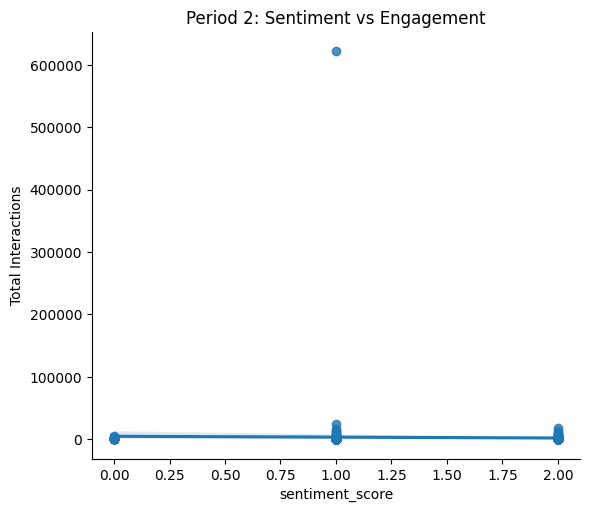

In [24]:
sns.lmplot(
    data=df_period1,
    x="sentiment_score",
    y="Total Interactions",
    height=5,
    aspect=1.2
)
plt.title("Period 1: Sentiment vs Engagement")

sns.lmplot(
    data=df_period2,
    x="sentiment_score",
    y="Total Interactions",
    height=5,
    aspect=1.2
)
plt.title("Period 2: Sentiment vs Engagement")

**Summary Table**

In [25]:
summary = pd.DataFrame({
    "Metric": ["Correlation (r)", "p-value", "Regression Coef"],
    "Period 1": [r1, p1, coef1],
    "Period 2": [r2, p2, coef2]
})

summary

,Metric,Period 1,Period 2
0,Correlation (r),-0.175744,-0.025395
1,p-value,0.248187,0.607268
2,Regression Coef,-600.747036,-1376.870926


# **Part 3. Intercoder Agreement**

**Data Preparation**

In [16]:
import pandas as pd

# Load file (skip messy headers)
df_ic = pd.read_excel("Intercoder.xlsx", header=3)
df_ic.head()


,Unnamed: 0,Unnamed: 1,Researcher,Male,Male.1,Female,Male.2,Female.1,Male.3
0,2023-07-31 22:19:49,This member from SM's upcoming boy group RIIZE...,1,1,1,1,1,2,1
1,2023-08-01 06:56:23,K-netizens react to an alleged pre-debut photo...,2,0,2,2,0,0,0
2,2023-08-05 12:54:50,SM Entertainment's upcoming boy group RIIZE br...,1,1,1,1,1,1,1
3,2023-08-09 21:44:49,"""Were their photos heavily edited?"" K-netizens...",2,2,2,2,2,2,2
4,2023-08-18 19:54:52,"""What's with their hair?"" RIIZE members' hairs...",2,2,2,2,2,2,2


In [17]:
df_ic = df_ic.rename(columns={
    df_ic.columns[2]: "Researcher",
    df_ic.columns[3]: "Coder1",
    df_ic.columns[4]: "Coder2",
    df_ic.columns[5]: "Coder3",
    df_ic.columns[6]: "Coder4",
    df_ic.columns[7]: "Coder5",
    df_ic.columns[8]: "Coder6"
})

# Keep only sentiment columns
df_ic = df_ic[["Researcher","Coder1","Coder2","Coder3","Coder4","Coder5","Coder6"]]

df_ic.head()

,Researcher,Coder1,Coder2,Coder3,Coder4,Coder5,Coder6
0,1,1,1,1,1,2,1
1,2,0,2,2,0,0,0
2,1,1,1,1,1,1,1
3,2,2,2,2,2,2,2
4,2,2,2,2,2,2,2


**Add AI Sentiment**

In [22]:
# Map AI labels to numeric (same coding as dataset)
label_map = {
    "Negative": 2,
    "Neutral": 0,
    "Positive": 1
}

df_ic["AI_sentiment"] = df["text_sentiment"][:len(df_ic)]
df_ic["AI_numeric"] = df_ic["AI_sentiment"].map(label_map)

In [23]:
df_ic["AI_sentiment"]

,AI_sentiment
0,Neutral
1,Positive
2,Neutral
3,Neutral
4,Positive
...,...
113,Neutral
114,Neutral
115,Neutral
116,Neutral


In [24]:
df_ic["AI_numeric"]

,AI_numeric
0,0
1,1
2,0
3,0
4,1
...,...
113,0
114,0
115,0
116,0


**Cohen's Kappa (AI vs Human)**

In [25]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
    df_ic["Researcher"],
    df_ic["AI_numeric"]
)

print("Cohen’s Kappa (AI vs Human):", kappa)

Cohen’s Kappa (AI vs Human): 0.0017754569190601144


**Cohen's Kappa (Researcher vs Each Coder)**

In [26]:
kappa_results = {}

for col in ["Coder1","Coder2","Coder3","Coder4","Coder5","Coder6"]:
    kappa_results[col] = cohen_kappa_score(df_ic["Researcher"], df_ic[col])

kappa_results

{'Coder1': np.float64(0.3824010467778869),
 'Coder2': np.float64(0.4993635977938058),
 'Coder3': np.float64(0.4335395775549392),
 'Coder4': np.float64(0.5362951642833751),
 'Coder5': np.float64(0.23462312681726682),
 'Coder6': np.float64(0.4919408257893575)}

**Average Kappa**

In [27]:
import numpy as np

avg_kappa = np.mean(list(kappa_results.values()))
print("Average Human Agreement (Kappa):", avg_kappa)

Average Human Agreement (Kappa): 0.4296938898361052


**Krippendorff Alpha**

In [28]:
!pip install krippendorff
import krippendorff

data = df_ic[["Researcher","Coder1","Coder2","Coder3","Coder4","Coder5","Coder6"]].to_numpy().T

alpha = krippendorff.alpha(reliability_data=data)

print("Krippendorff’s Alpha:", alpha)

Krippendorff’s Alpha: 0.3214432868326563


**Confusion Matrix (AI vs Human)**

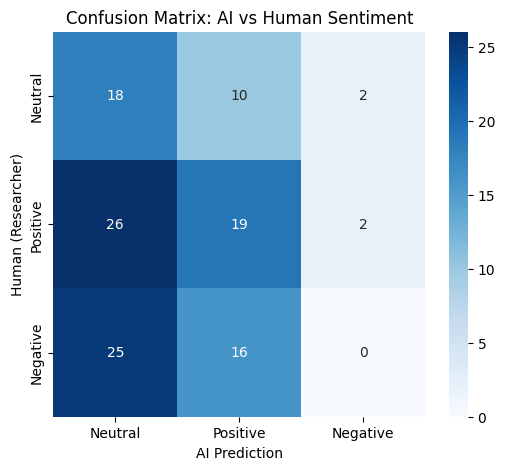

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = [0, 1, 2]  # Neutral, Positive, Negative

cm = confusion_matrix(
    df_ic["Researcher"],
    df_ic["AI_numeric"],
    labels=labels
)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neutral","Positive","Negative"],
            yticklabels=["Neutral","Positive","Negative"])

plt.xlabel("AI Prediction")
plt.ylabel("Human (Researcher)")
plt.title("Confusion Matrix: AI vs Human Sentiment")
plt.show()

**Majority Vote Comparison**

In [31]:
from scipy.stats import mode

coders_only = df_ic[["Coder1","Coder2","Coder3","Coder4","Coder5","Coder6"]]
df_ic["Majority"] = mode(coders_only, axis=1)[0]

In [32]:
df_ic["Majority"]

,Majority
0,1
1,0
2,1
3,2
4,2
...,...
113,1
114,1
115,0
116,2
